In [1]:
using Pkg 

In [2]:
# Pkg.add("JuMP")
# Pkg.add("Gurobi")

In [ ]:
using JuMP, Gurobi
using Plots

## A first example
Let's see how we translate the tables-and-chairs example we just saw into Julia code.

$$
\begin{align*}
\max_{x_1,x_2} \quad
& 20 x_1 + 30 x_2 
\\
\text{such that} \quad
& x_1 + 2 x_2 \leq 30 \\
& 10 x_1 + 5 x_2 \leq 120 \\
& x_1, x_2 \geq 0.
\end{align*}
$$

We construct a model object. This is a container for everything in our optimization problem: variables, constraints, solver options, etc.

Note that when we specify the solver we can also pass additional arguments (depending on the solver we choose). 
If you're experimenting with an optimization model, it's generally a good idea to set a short time limit for the solver calculations. This will (hopefully) force the solver to stop running if you accidentally pass it a very large model that it can't solve. 

In [49]:
model = Model(Gurobi.Optimizer)
set_optimizer_attribute(model, "TimeLimit", 60)

Set parameter Username
Set parameter LicenseID to value 2666310
Academic license - for non-commercial use only - expires 2026-05-14
Set parameter TimeLimit to value 60


Next, we define the two decision variables in our optimization problem. We will use the ``@variable`` macro (a fancy function, essentially). The first argument is the model object to attach the variable to, and the second specifies the variable name and any bounds.

In [50]:
@variable(model, x[1:2] ≥ 0)

2-element Vector{VariableRef}:
 x[1]
 x[2]

In [51]:
model

A JuMP Model
├ solver: Gurobi
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 2
├ num_constraints: 2
│ └ VariableRef in MOI.GreaterThan{Float64}: 2
└ Names registered in the model
  └ :x

We now add the constraints of our problem using the ``@constraint`` macro:

In [52]:
# Labor constraint
@constraint(model, 1 * x[1] + 2 * x[2] <= 30)
# Wood constraint
@constraint(model, 10 * x[1] + 5 * x[2] <= 120)
;

In [53]:
model

A JuMP Model
├ solver: Gurobi
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 2
├ num_constraints: 4
│ ├ AffExpr in MOI.LessThan{Float64}: 2
│ └ VariableRef in MOI.GreaterThan{Float64}: 2
└ Names registered in the model
  └ :x

We specify the objective function with the ``@objective`` macro.

In [54]:
@objective(model, Max, 20 * x[1] + 30 * x[2])

20 x[1] + 30 x[2]

In [55]:
model

A JuMP Model
├ solver: Gurobi
├ objective_sense: MAX_SENSE
│ └ objective_function_type: AffExpr
├ num_variables: 2
├ num_constraints: 4
│ ├ AffExpr in MOI.LessThan{Float64}: 2
│ └ VariableRef in MOI.GreaterThan{Float64}: 2
└ Names registered in the model
  └ :x

To solve the optimization problem, call the ``optimize!`` function.

In [56]:
optimize!(model)
termination_status(model)

Set parameter TimeLimit to value 60
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M2 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 2 rows, 2 columns and 4 nonzeros
Model fingerprint: 0xdadcd0d8
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [2e+01, 3e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+01, 1e+02]
Presolve time: 0.00s
Presolved: 2 rows, 2 columns, 4 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    5.0000000e+31   3.375000e+30   5.000000e+01      0s
       2    4.8000000e+02   0.000000e+00   0.000000e+00      0s

Solved in 2 iterations and 0.00 seconds (0.00 work units)
Optimal objective  4.800000000e+02

User-callback calls 47, time in user-callback 0.00 sec


OPTIMAL::TerminationStatusCode = 1

We can now inspect the solution values and optimal cost.

In [75]:
x_sol = JuMP.value.(x)
x_sol

2-element Vector{Float64}:
  6.0
 12.0

In [58]:
JuMP.objective_value(model)

480.0

This means that one should build 6 tables (the value of $x_1$) and 12 chairs (the value of $x_2$) in order to maximize profit. This would result in $480 of profit.

We can also visualize the feasible region and optimal solution via `Plots.jl`. Here is a worked example:

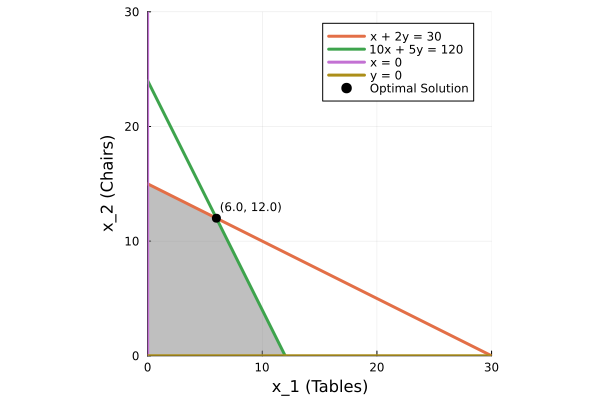

In [90]:
xmax = 30
ymax = 30
Plots.plot(
    xlabel="x_1 (Tables)", 
    ylabel="x_2 (Chairs)",  
    legend=:topright,
    aspect_ratio=:equal,
    xlims=(0, xmax),
    ylims=(0, ymax),
)
feasible_region = Shape(
    [ 
        (0, 0),
        (12, 0),
        (6, 12),
        (0, 15),
        (0, 0)
    ]
)
Plots.plot!(
    feasible_region, 
    fillcolor=:gray,
    fillalpha=0.5,
    label=false,
)
Plots.plot!(
    [(x, (30-x)/2) for x in 0:0.1:xmax], 
    label="x + 2y = 30", 
    linewidth=3,
)
Plots.plot!(
    [(x, (120-10*x)/5) for x in 0:0.1:xmax], 
    label="10x + 5y = 120", 
    linewidth=3,
)
Plots.plot!(
    [(0, y) for y in 0:0.1:ymax], 
    label="x = 0", 
    linewidth=3,
)
Plots.plot!(
    [(x, 0) for x in 0:0.1:xmax], 
    label="y = 0", 
    linewidth=3,
)
Plots.scatter!(
    [x_sol[1]], 
    [x_sol[2]], 
    label="Optimal Solution", 
    color=:black, 
    markersize=5
)
Plots.annotate!(
    x_sol[1] + 3, 
    x_sol[2] + 1, 
    text(
        "($(string(x_sol[1])), $(string(x_sol[2])))",
        :black,
        8,
        :center,
    )
)


## Exercise 1

Code and solve the following optimization problem:

$$
\begin{align*}
\min_{x,y} \quad& 3x - y \\
\text{s.t.}\quad& x + 2y \geq 1 \\
& x \geq 0 \\
& 0 \leq y \leq 1.
\end{align*}
$$

In [4]:
model = Model(optimizer_with_attributes(Gurobi.Optimizer, "Presolve"=>0, "OutputFlag"=>1))
set_time_limit_sec(model, 60.0)

@variable(model, x >= 0)
@variable(model, 0 <= y <= 1)
@constraint(model, x + 2*y >= 1)
@objective(model, Min, 3*x - y)

print(model)

Set parameter Username
Set parameter LicenseID to value 2666310
Academic license - for non-commercial use only - expires 2026-05-14
Set parameter Presolve to value 0
Set parameter TimeLimit to value 60
Min 3 x - y
Subject to
 x + 2 y ≥ 1
 x ≥ 0
 y ≥ 0
 y ≤ 1


In [5]:
optimize!(model)
println("Solution: ")
println("    x: ", value(x))
println("    y: ", value(y))
println("Objective: ", objective_value(model))

Set parameter TimeLimit to value 60
Set parameter Presolve to value 0
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M2 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1 rows, 2 columns and 2 nonzeros
Model fingerprint: 0xc187175f
Coefficient statistics:
  Matrix range     [1e+00, 2e+00]
  Objective range  [1e+00, 3e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -1.0000000e+00   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.00 seconds (0.00 work units)
Optimal objective -1.000000000e+00

User-callback calls 20, time in user-callback 0.00 sec
Solution: 
    x: 0.0
    y: 1.0
Objective: -1.0


## Exercise 2

Take the problem from exercise 1 and make two copies below.
* In the first copy, add a new constraint to make the problem **infeasible** (i.e., there are no values of x and y that satisfy all the constraints)
* In the second copy, change the constraints or the objective function to make the problem unbounded (i.e., the optimal solution is infinite)

Solve both versions of the problem and look at the ``termination_status`` to see if you have succeeded.

Hint: below is code that plots the feasible region of the model from Exercise 1:

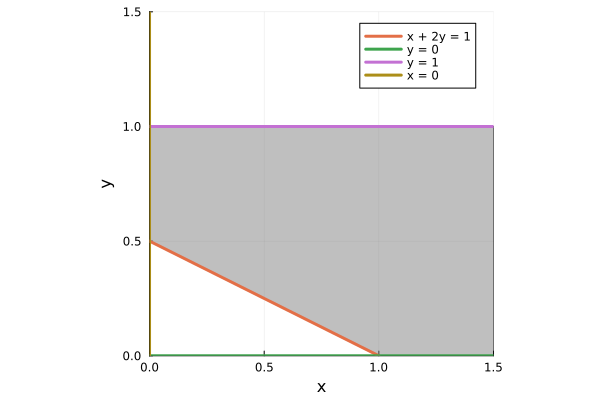

In [44]:
xmax = 1.5
ymax = 1.5
Plots.plot(
    xlabel="x", 
    ylabel="y",  
    legend=:topright,
    aspect_ratio=:equal,
    xlims=(0, xmax),
    ylims=(0, ymax),
)
feasible_region = Shape(
    [ 
        (0, 0.5),
        (1, 0),
        (1.5, 0),
        (1.5, 1),
        (0, 1),
    ]
)
Plots.plot!(
    feasible_region, 
    fillcolor=:gray,
    fillalpha=0.5,
    label=false,
)
Plots.plot!(
    [(x, (1-x)/2) for x in 0:0.1:xmax], 
    label="x + 2y = 1", 
    linewidth=3,
)
Plots.plot!(
    [(x, 0) for x in 0:0.1:xmax], 
    label="y = 0", 
    linewidth=3,
)
Plots.plot!(
    [(x, 1) for x in 0:0.1:xmax], 
    label="y = 1", 
    linewidth=3,
)
Plots.plot!(
    [(0, y) for y in 0:0.1:ymax], 
    label="x = 0", 
    linewidth=3,
)

In [45]:
model1 = Model(Gurobi.Optimizer)
set_time_limit_sec(model, 60.0)

@variable(model1, x >= 0)
@variable(model1, 1 >= y >= 0)
@constraint(model1, x + 2*y >= 1)
@constraint(model1, x + 2*y <= 0) # Extra constraint to make the problem infeasible
@objective(model1, Min, 3*x - y)

print(model1)
optimize!(model1)
termination_status(model1)

Set parameter Username
Set parameter LicenseID to value 2666310
Academic license - for non-commercial use only - expires 2026-05-14
Min 3 x - y
Subject to
 x + 2 y ≥ 1
 x + 2 y ≤ 0
 x ≥ 0
 y ≥ 0
 y ≤ 1
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M2 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 2 rows, 2 columns and 4 nonzeros
Model fingerprint: 0xe3398fff
Coefficient statistics:
  Matrix range     [1e+00, 2e+00]
  Objective range  [1e+00, 3e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 1 rows and 2 columns
Presolve time: 0.00s

Solved in 0 iterations and 0.00 seconds (0.00 work units)
Infeasible model

User-callback calls 19, time in user-callback 0.00 sec


INFEASIBLE::TerminationStatusCode = 2

In [48]:
model2 = Model(Gurobi.Optimizer)
set_attribute(model2, "InfUnbdInfo", 1) # Diagnoses unboundedness
set_time_limit_sec(model2, 60.0)

@variable(model2, x >= 0)
@variable(model2, 1 >= y >= 0)
@constraint(model2, x + 2*y >= 1)
@objective(model2, Max, x)

print(model2)
optimize!(model2)
termination_status(model2)

Set parameter Username
Set parameter LicenseID to value 2666310
Academic license - for non-commercial use only - expires 2026-05-14
Set parameter InfUnbdInfo to value 1
Set parameter TimeLimit to value 60
Max x
Subject to
 x + 2 y ≥ 1
 x ≥ 0
 y ≥ 0
 y ≤ 1
Set parameter InfUnbdInfo to value 1
Set parameter TimeLimit to value 60
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M2 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1 rows, 2 columns and 2 nonzeros
Model fingerprint: 0x32af2707
Coefficient statistics:
  Matrix range     [1e+00, 2e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolve time: 0.00s
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.0000000e+30   0.000000e+00   2.000000e+00      0s

Solved in 0 iterations and 0.00 seconds (0.00 work units)
Unbounded model

User-callbac

DUAL_INFEASIBLE::TerminationStatusCode = 3

## Helpful resources

Here are some helpful links for your reference:
- A introduction to Julia on the JuMP website: [(link)](https://jump.dev/JuMP.jl/stable/tutorials/getting_started/getting_started_with_julia/)
- [The JuMP tutorial](https://jump.dev/JuMP.jl/stable/tutorials/getting_started/getting_started_with_JuMP/)
- the JuMP manual ([models](https://jump.dev/JuMP.jl/stable/manual/models/), [variables](https://jump.dev/JuMP.jl/stable/manual/variables/) and [constraints](https://jump.dev/JuMP.jl/stable/manual/constraints/))
- in the Gurobi documentation, [guidelines](https://www.gurobi.com/documentation/11.0/refman/mip_models.html) for parameter settings for MIP models (come back to this later)
- Packages to know in Julia:
    - [`DataFrames.jl`](https://dataframes.juliadata.org/stable/) for working with dataframes
    - [`Plots.jl`](https://docs.juliaplots.org/latest/) for plotting (among a few options)
- A [list](https://docs.julialang.org/en/v1/manual/noteworthy-differences/) of differences between Julia and other languages